In [17]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
import sys
sys.path.append("..")  # remonte d'un niveau, jusqu'à PFAPROJECT/

from pipeline.tables import load_data
from pipeline.dataquality import run_data_quality


In [19]:
tables = load_data()

=== transfers : hadm_id manquant ===
Lignes concernées : 54 sur 1190 (4.5%)


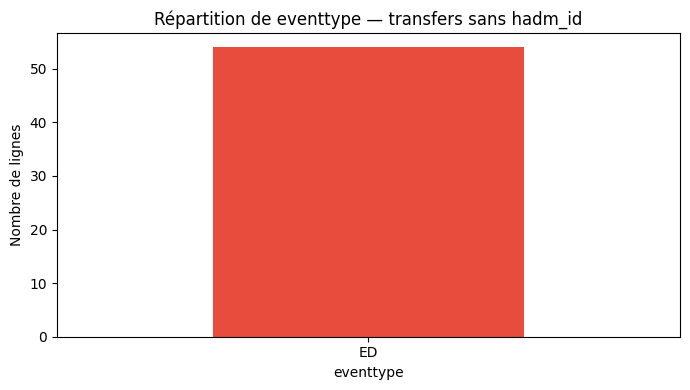

In [20]:
transfers = tables["transfers"]

transfers_sans_hadm = transfers[transfers["hadm_id"].isnull()]

print(f"=== transfers : hadm_id manquant ===")
print(f"Lignes concernées : {len(transfers_sans_hadm)} sur {len(transfers)} ({len(transfers_sans_hadm)/len(transfers)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
transfers_sans_hadm["eventtype"].value_counts().plot(kind="bar", ax=ax, color="#e74c3c")
ax.set_title("Répartition de eventtype — transfers sans hadm_id")
ax.set_xlabel("eventtype")
ax.set_ylabel("Nombre de lignes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
display(
    transfers_sans_hadm[["subject_id", "hadm_id", "eventtype"]]
    .sort_values(by="subject_id")
)

,subject_id,hadm_id,eventtype
236,10001217,NaN,ED
218,10001725,NaN,ED
1165,10002428,NaN,ED
1058,10004720,NaN,ED
340,10005866,NaN,ED
342,10005866,NaN,ED
195,10006580,NaN,ED
770,10012853,NaN,ED
769,10012853,NaN,ED
767,10012853,NaN,ED


=== emar : hadm_id manquant ===
Lignes concernées : 1006 sur 35835 (2.8%)
Patients concernés : 21
  → dont patients ED : 21
  → dont patients hors ED : 0


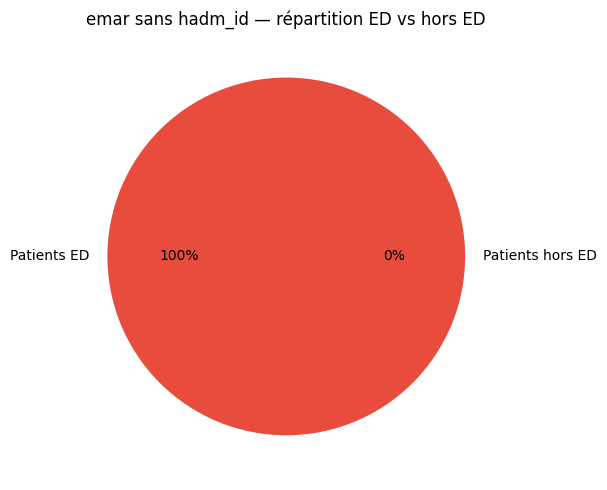

In [22]:
emar = tables["emar"]

emar_sans_hadm = emar[emar["hadm_id"].isnull()]
patients_ed = set(transfers[transfers["eventtype"] == "ED"]["subject_id"])
patients_emar_sans_hadm = set(emar_sans_hadm["subject_id"].unique())

correspondance = patients_emar_sans_hadm & patients_ed
hors_ed = patients_emar_sans_hadm - patients_ed

print(f"=== emar : hadm_id manquant ===")
print(f"Lignes concernées : {len(emar_sans_hadm)} sur {len(emar)} ({len(emar_sans_hadm)/len(emar)*100:.1f}%)")
print(f"Patients concernés : {len(patients_emar_sans_hadm)}")
print(f"  → dont patients ED : {len(correspondance)}")
print(f"  → dont patients hors ED : {len(hors_ed)}")

fig, ax = plt.subplots(figsize=(6, 5))
labels = ["Patients ED", "Patients hors ED"]
valeurs = [len(correspondance), len(hors_ed)]
ax.pie(valeurs, labels=labels, autopct="%1.0f%%", colors=["#e74c3c", "#3498db"])
ax.set_title("emar sans hadm_id — répartition ED vs hors ED")
plt.tight_layout()
plt.show()

=== emar : couverture medication par patient ===
Total patients dans emar : 65
Patients avec au moins un médicament : 65
Patients SANS aucun médicament : 0


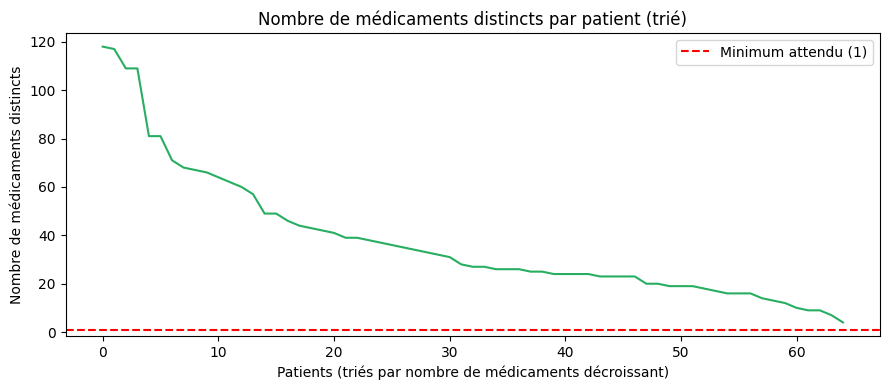

In [23]:
patients_avec_medication = set(emar[emar["medication"].notnull()]["subject_id"].unique())
tous_patients_emar = set(emar["subject_id"].unique())
sans_aucun_medicament = tous_patients_emar - patients_avec_medication

print(f"=== emar : couverture medication par patient ===")
print(f"Total patients dans emar : {len(tous_patients_emar)}")
print(f"Patients avec au moins un médicament : {len(patients_avec_medication)}")
print(f"Patients SANS aucun médicament : {len(sans_aucun_medicament)}")

# Courbe : nombre de médicaments distincts par patient, triée
medicaments_par_patient = emar[emar["medication"].notnull()].groupby("subject_id")["medication"].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(medicaments_par_patient)), medicaments_par_patient.values, color="#27ae60")
ax.set_title("Nombre de médicaments distincts par patient (trié)")
ax.set_xlabel("Patients (triés par nombre de médicaments décroissant)")
ax.set_ylabel("Nombre de médicaments distincts")
ax.axhline(y=1, color="red", linestyle="--", label="Minimum attendu (1)")
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
microbiologyevents = tables["microbiologyevents"]
sans_hadm_micro = microbiologyevents[microbiologyevents["hadm_id"].isnull()]

patients_ed = set(transfers[transfers["eventtype"] == "ED"]["subject_id"])
patients_sans_hadm_micro = set(sans_hadm_micro["subject_id"].unique())
patients_hors_ed_micro = patients_sans_hadm_micro - patients_ed

print(f"Patients hors ED : {len(patients_hors_ed_micro)}")

Patients hors ED : 11


In [25]:
admissions = tables["admissions"]
leurs_admissions = admissions[admissions["subject_id"].isin(patients_hors_ed_micro)].copy()
leurs_admissions["duree_sejour"] = (leurs_admissions["dischtime"] - leurs_admissions["admittime"]).dt.days

print(leurs_admissions["duree_sejour"].describe())

count    16.000000
mean      4.437500
std       2.032035
min       0.000000
25%       3.750000
50%       4.500000
75%       6.000000
max       8.000000
Name: duree_sejour, dtype: float64


In [26]:
def verifier_dans_sejour(sans_hadm_micro_df, admissions_df):
    resultats = []
    for _, row in sans_hadm_micro_df.iterrows():
        sejours_patient = admissions_df[admissions_df["subject_id"] == row["subject_id"]]
        match = sejours_patient[
            (sejours_patient["admittime"] <= row["chartdate"]) &
            (sejours_patient["dischtime"] >= row["chartdate"])
        ]
        resultats.append(len(match) > 0)
    return resultats

sans_hadm_micro_hors_ed = sans_hadm_micro[sans_hadm_micro["subject_id"].isin(patients_hors_ed_micro)].copy()
sans_hadm_micro_hors_ed["dans_un_sejour"] = verifier_dans_sejour(sans_hadm_micro_hors_ed, admissions)

print(sans_hadm_micro_hors_ed["dans_un_sejour"].value_counts())

dans_un_sejour
False    38
True     15
Name: count, dtype: int64


In [27]:
sans_hadm_micro_hors_ed_grouped = sans_hadm_micro_hors_ed.groupby("subject_id")["dans_un_sejour"].agg(["sum", "count"])
sans_hadm_micro_hors_ed_grouped["taux"] = sans_hadm_micro_hors_ed_grouped["sum"] / sans_hadm_micro_hors_ed_grouped["count"]
print(sans_hadm_micro_hors_ed_grouped)

print(f"\nPatients où AUCUNE ligne ne tombe dans un séjour : {(sans_hadm_micro_hors_ed_grouped['sum'] == 0).sum()}")
print(f"Patients où TOUTES les lignes tombent dans un séjour : {(sans_hadm_micro_hors_ed_grouped['taux'] == 1).sum()}")
print(f"Patients mixtes : {((sans_hadm_micro_hors_ed_grouped['taux'] > 0) & (sans_hadm_micro_hors_ed_grouped['taux'] < 1)).sum()}")

            sum  count  taux
subject_id                  
10005348      0      2   0.0
10008287      0      1   0.0
10009035      0      2   0.0
10011398      0      3   0.0
10013049      0      3   0.0
10019172      1      1   1.0
10021312     14     14   1.0
10022017      0      2   0.0
10023771      0      8   0.0
10031404      0      9   0.0
10038992      0      8   0.0

Patients où AUCUNE ligne ne tombe dans un séjour : 9
Patients où TOUTES les lignes tombent dans un séjour : 2
Patients mixtes : 0


In [28]:
for patient_id in list(patients_hors_ed_micro)[:11]:
    sejours = admissions[admissions["subject_id"] == patient_id]
    print(f"Patient {patient_id} : {len(sejours)} séjour(s) dans admissions")
    print(sejours["hadm_id"])

Patient 10021312 : 2 séjour(s) dans admissions
24    25020332
25    28829452
Name: hadm_id, dtype: int64
Patient 10022017 : 1 séjour(s) dans admissions
266    22342963
Name: hadm_id, dtype: int64
Patient 10005348 : 3 séjour(s) dans admissions
40     29496232
72     25239799
245    29176490
Name: hadm_id, dtype: int64
Patient 10019172 : 2 séjour(s) dans admissions
41    24997044
42    21540783
Name: hadm_id, dtype: int64
Patient 10011398 : 1 séjour(s) dans admissions
257    27505812
Name: hadm_id, dtype: int64
Patient 10009035 : 1 séjour(s) dans admissions
49    28324362
Name: hadm_id, dtype: int64
Patient 10031404 : 1 séjour(s) dans admissions
4    21606243
Name: hadm_id, dtype: int64
Patient 10038992 : 2 séjour(s) dans admissions
29     22797747
270    24745425
Name: hadm_id, dtype: int64
Patient 10013049 : 1 séjour(s) dans admissions
44    22675517
Name: hadm_id, dtype: int64
Patient 10023771 : 1 séjour(s) dans admissions
39    20044587
Name: hadm_id, dtype: int64
Patient 10008287 : 

In [29]:
print("=" * 60)
print("EXÉCUTION — DATA QUALITY PAR TABLE")
print("=" * 60)

run_data_quality()

print("\n Les 12 checks par table ont été exécutés")

EXÉCUTION — DATA QUALITY PAR TABLE
completness:check
validityvalue:check
validity: complétude OK 
comparaison_date:check
comparaison_date:check
consistency:coherence ok
uniqeness:check
completness:check
d_icd_diagnoses : complétude OK
uniqeness:check
d_icd_diagnoses : unicité OK
validityvalue:check
d_icd_diagnoses : validity OK
completness:check
d_icd_procedures : complétude OK
uniqeness:check
d_icd_procedures : unicité OK
validityvalue:check
d_icd_procedures : validity OK
validityvalue:check
completness:check
uniqeness:check
completness:check
emar : chaque subject_id a au moins une valeur dans medication
emar : complétude OK
uniqeness:check
emar : unicité OK
emar : accuracy OK
uniqeness:check
completness:check
validity:check
uniqeness:check
completness:check
validity:check
uniqeness:check
completness:check
validityrang:check
uniqeness:check
completness:check
validity:check
validityvalue:check
completness:check
uniqeness:check
completness:check
validity:check
uniqeness:check
uniqeness: